# F1 Strategy Model Training
Trains a multi-task GRU model for F1 strategy prediction.
Run after 1_build_dataset.py has created the dataset.

2026-05-12 12:07:49.916478: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-12 12:07:49.930451: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-12 12:07:49.946675: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-12 12:07:49.951654: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-12 12:07:49.964702: I tensorflow/core/platform/cpu_feature_guar

Configuring TensorFlow for memory efficiency...
✓ Enabled memory growth for 1 GPU(s)
✓ Enabled mixed precision training

Loading Dataset
✓ Loaded dataset: 1450 samples
✓ After dropping rare stop classes (<5): 1449 samples
✓ Loaded weather sequences: 1449 sequences

Preprocessing Data
  Teams: 19
  Tracks: 45
  Starting compounds: 5
  Stop counts: 10
  Target compounds: 8
✓ Preprocessed 1449 samples
  Weather sequence shape: (1449, 290, 5)
  Max timesteps: 290

✓ Split: 1231 train, 218 test

Building Model


2026-05-12 12:07:52.242550: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 69381 MB memory:  -> device: 0, name: NVIDIA H100 NVL, pci bus id: 0000:e1:00.0, compute capability: 9.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ weather_seq         │ (None, 290, 5)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ team_in             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ track_in            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_comp_in       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 290, 5)    │          0 │ weather_seq[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ team_emb            │ (None, 1, 16)     │        304 │ team_in[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ track_emb           │ (None, 1, 16)     │        720 │ track_in[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_emb           │ (None, 1, 16)     │         80 │ start_comp_in[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_in (InputLayer) │ (None, 25)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weather_gru (GRU)   │ (None, 128)       │     51,840 │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ team_emb[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16)        │          0 │ track_emb[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 16)        │          0 │ start_emb[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 25)        │          0 │ num_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 201)       │          0 │ weather_gru[0][0… │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ cast_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 96)        │     19,392 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 96)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 96)        │      9,312 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 96)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

...

 Trainable params: 83,491 (326.14 KB)

 Non-trainable params: 0 (0.00 B)

None

Training Model
Epoch 1/100


2026-05-12 12:07:56.251828: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


77/77 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - loss: 4.7344 - stops_out_accuracy: 0.0771 - stops_out_loss: 2.1898 - time_out_loss: 1.1033 - time_out_mae: 0.6563 - tire_out_accuracy: 0.1795 - tire_out_loss: 1.8543 - val_loss: 4.9405 - val_stops_out_accuracy: 0.1284 - val_stops_out_loss: 2.2592 - val_time_out_loss: 1.0908 - val_time_out_mae: 0.6195 - val_tire_out_accuracy: 0.1881 - val_tire_out_loss: 1.9958 - learning_rate: 3.0000e-04
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 4.3776 - stops_out_accuracy: 0.1518 - stops_out_loss: 2.0310 - time_out_loss: 0.9809 - time_out_mae: 0.6352 - tire_out_accuracy: 0.1846 - tire_out_loss: 1.7213 - val_loss: 4.7943 - val_stops_out_accuracy: 0.1789 - val_stops_out_loss: 2.1838 - val_time_out_loss: 1.0502 - val_time_out_mae: 0.6134 - val_tire_out_accuracy: 0.2064 - val_tire_out_loss: 1.9496 - learning_rate: 3.0000e-04
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 4.1082 - stops_out_accuracy: 0.1991 - stops_out_loss: 1.8954 - 

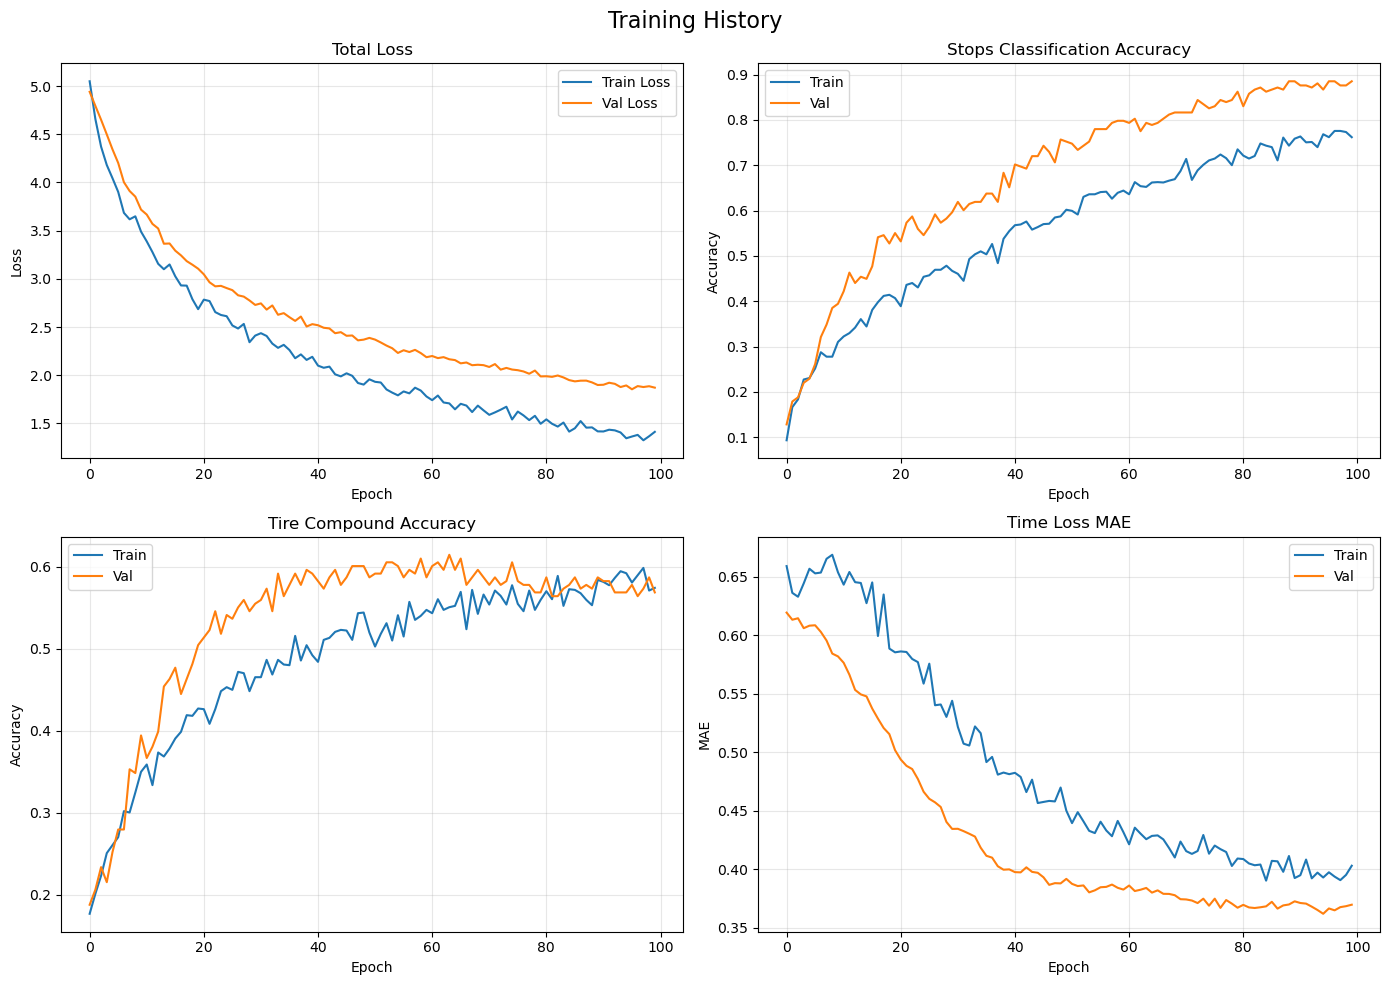

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# --------------------
# CUDA Memory Configuration
# --------------------
print("Configuring TensorFlow for memory efficiency...")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ Enabled memory growth for {len(gpus)} GPU(s)")
        tf.keras.mixed_precision.set_global_policy("mixed_float16")
        print("✓ Enabled mixed precision training")
    except RuntimeError as e:
        print(f"Memory growth setting error: {e}")
else:
    tf.keras.mixed_precision.set_global_policy("float32")
    print("✓ Using float32 on CPU")

# --------------------
# Configuration
# --------------------
np.random.seed(42)
tf.random.set_seed(42)

# Input files (created by 1_build_dataset.py)
INPUT_DATASET = "f1_strategy_dataset.csv"
INPUT_WEATHER_SEQS = "f1_weather_sequences.npz"

# Output files
MODEL_FILE = "multitask_strategy_model.keras"
PREPROC_FILE = "multitask_preprocessing.joblib"
HISTORY_PLOT = "training_history.png"

WEATHER_FEATURES = ["air_temperature", "track_temperature", "humidity", "rainfall", "wind_speed"]

# Model hyperparameters (reduced to mitigate overfitting)
EMBED_DIM = 16
GRU_UNITS = 128
DENSE_UNITS = 96
BATCH_SIZE = 16
EPOCHS = 100
PATIENCE = 5

# --------------------
# Data Loading
# --------------------
print("\n" + "="*60)
print("Loading Dataset")
print("="*60)

assert Path(INPUT_DATASET).exists(), f"Dataset not found: {INPUT_DATASET}\nRun 1_build_dataset.py first!"
assert Path(INPUT_WEATHER_SEQS).exists(), f"Weather sequences not found: {INPUT_WEATHER_SEQS}\nRun 1_build_dataset.py first!"

df = pd.read_csv(INPUT_DATASET)
print(f"✓ Loaded dataset: {len(df)} samples")

# Drop rare stop classes
min_count = 5
stop_counts = df["stops"].astype(str).value_counts()
keep_mask = df["stops"].astype(str).map(stop_counts) >= min_count
df = df[keep_mask].reset_index(drop=True)
print(f"✓ After dropping rare stop classes (<{min_count}): {len(df)} samples")

# Load weather sequences
weather_data = np.load(INPUT_WEATHER_SEQS, allow_pickle=True)
X_seq = [weather_data[f"seq_{i}"] for i in range(len(df))]
print(f"✓ Loaded weather sequences: {len(X_seq)} sequences")

# --------------------
# Preprocessing
# --------------------
print("\n" + "="*60)
print("Preprocessing Data")
print("="*60)

# Clip outliers
COLS_TO_CLIP = [
    "starting_position", "time_loss_sec",
    "air_temp_mean", "air_temp_std",
    "track_temp_mean", "track_temp_std",
    "humidity_mean", "humidity_std",
    "rain_minutes_ratio", "rain_rate_mean", "rain_rate_std",
    "wind_speed_mean", "wind_speed_std",
    "temp_delta_mean", "rain_change_rate",
    "total_stint_laps", "avg_stint_laps", "max_stint_laps", "num_stints",
    "total_laps", "mean_tyre_life", "max_tyre_life",
    "mean_lap_time_sec", "lap_time_std_sec", "pace_trend_per_lap",
    "non_green_lap_ratio",
]

for c in COLS_TO_CLIP:
    if c in df.columns:
        q01 = df[c].quantile(0.01)
        q99 = df[c].quantile(0.99)
        df[c] = df[c].clip(lower=q01, upper=q99)

# Label encoders
team_le = LabelEncoder().fit(df["team_name"].fillna("Unknown"))
track_le = LabelEncoder().fit(df["track_name"].fillna("Unknown"))
start_le = LabelEncoder().fit(df["starting_compound"].fillna("MEDIUM"))
stops_le = LabelEncoder().fit(df["stops"].astype(str))
tire_le = LabelEncoder().fit(df["target_compound"].fillna("MEDIUM"))

df["team_idx"] = team_le.transform(df["team_name"].fillna("Unknown"))
df["track_idx"] = track_le.transform(df["track_name"].fillna("Unknown"))
df["start_idx"] = start_le.transform(df["starting_compound"].fillna("MEDIUM"))
df["stops_idx"] = stops_le.transform(df["stops"].astype(str))
df["tire_idx"] = tire_le.transform(df["target_compound"].fillna("MEDIUM"))

print(f"  Teams: {len(team_le.classes_)}")
print(f"  Tracks: {len(track_le.classes_)}")
print(f"  Starting compounds: {len(start_le.classes_)}")
print(f"  Stop counts: {len(stops_le.classes_)}")
print(f"  Target compounds: {len(tire_le.classes_)}")

# Numeric features
NUM_COLS = [
    "starting_position",
    "air_temp_mean", "air_temp_std",
    "track_temp_mean", "track_temp_std",
    "humidity_mean", "humidity_std",
    "rain_minutes_ratio", "rain_rate_mean", "rain_rate_std",
    "wind_speed_mean", "wind_speed_std",
    "temp_delta_mean", "rain_change_rate",
    "total_stint_laps", "avg_stint_laps", "max_stint_laps", "num_stints",
    "total_laps", "mean_tyre_life", "max_tyre_life",
    "mean_lap_time_sec", "lap_time_std_sec", "pace_trend_per_lap",
    "non_green_lap_ratio",
]

X_num = df[NUM_COLS].fillna(0).values.astype("float32")
X_num_mean = X_num.mean(axis=0)
X_num_std = X_num.std(axis=0) + 1e-8
X_num = (X_num - X_num_mean) / X_num_std

# Weather sequences - pad and normalize
max_timesteps = max(seq.shape[0] for seq in X_seq)
X_seq_pad = pad_sequences(X_seq, maxlen=max_timesteps, padding="post", dtype="float32")

seq_mean = X_seq_pad.mean(axis=(0, 1))
seq_std = X_seq_pad.std(axis=(0, 1)) + 1e-8
X_seq_norm = (X_seq_pad - seq_mean) / seq_std

# Target: time_loss (log transform + normalize)
y_time = np.log1p(df["time_loss_sec"].values).astype("float32")
y_time_mean = y_time.mean()
y_time_std = y_time.std() + 1e-8
y_time_norm = (y_time - y_time_mean) / y_time_std

print(f"✓ Preprocessed {len(df)} samples")
print(f"  Weather sequence shape: {X_seq_norm.shape}")
print(f"  Max timesteps: {max_timesteps}")

# --------------------
# Train/Test Split (stratify if possible)
# --------------------
indices = np.arange(len(df))
class_counts = df["stops_idx"].value_counts()

if class_counts.min() < 2:
    print("⚠️ Not enough samples in at least one class; using non-stratified split.")
    train_idx, test_idx = train_test_split(
        indices, test_size=0.15, random_state=42, shuffle=True
    )
else:
    train_idx, test_idx = train_test_split(
        indices, test_size=0.15, random_state=42,
        stratify=df["stops_idx"].values
    )

print(f"\n✓ Split: {len(train_idx)} train, {len(test_idx)} test")

# --------------------
# Model Building
# --------------------
print("\n" + "="*60)
print("Building Model")
print("="*60)

# Inputs
weather_seq_in = keras.Input(shape=(max_timesteps, len(WEATHER_FEATURES)), name="weather_seq")
team_in = keras.Input(shape=(1,), dtype="int32", name="team_in")
track_in = keras.Input(shape=(1,), dtype="int32", name="track_in")
start_comp_in = keras.Input(shape=(1,), dtype="int32", name="start_comp_in")
num_in = keras.Input(shape=(len(NUM_COLS),), name="num_in")

# Embeddings
team_emb = layers.Embedding(len(team_le.classes_), EMBED_DIM, name="team_emb")(team_in)
team_emb = layers.Flatten()(team_emb)

track_emb = layers.Embedding(len(track_le.classes_), EMBED_DIM, name="track_emb")(track_in)
track_emb = layers.Flatten()(track_emb)

start_emb = layers.Embedding(len(start_le.classes_), EMBED_DIM, name="start_emb")(start_comp_in)
start_emb = layers.Flatten()(start_emb)

# Weather GRU
weather_gru = layers.GRU(
    GRU_UNITS,
    return_sequences=False,
    kernel_regularizer=regularizers.l2(0.001),
    name="weather_gru"
)(weather_seq_in)

# Concatenate all features
concat = layers.Concatenate()([weather_gru, team_emb, track_emb, start_emb, num_in])

# Shared representation
shared = layers.Dense(DENSE_UNITS, activation="relu", kernel_regularizer=regularizers.l2(0.001))(concat)
shared = layers.Dropout(0.3)(shared)
shared = layers.Dense(DENSE_UNITS, activation="relu")(shared)
shared = layers.Dropout(0.3)(shared)

# Task-specific heads
stops_out = layers.Dense(len(stops_le.classes_), activation="softmax", name="stops_out")(shared)
tire_out = layers.Dense(len(tire_le.classes_), activation="softmax", name="tire_out")(shared)
time_out = layers.Dense(1, activation="linear", name="time_out")(shared)

model = keras.Model(
    inputs=[weather_seq_in, team_in, track_in, start_comp_in, num_in],
    outputs={"stops_out": stops_out, "tire_out": tire_out, "time_out": time_out}
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss={
        "stops_out": "sparse_categorical_crossentropy",
        "tire_out": "sparse_categorical_crossentropy",
        "time_out": "mse"
    },
    loss_weights={"stops_out": 1.0, "tire_out": 1.0, "time_out": 0.5},
    metrics={
        "stops_out": ["accuracy"],
        "tire_out": ["accuracy"],
        "time_out": ["mae"]
    }
)

print(model.summary())

# --------------------
# Training
print("\n" + "="*60)
print("Training Model")
print("="*60)

X_train = {
    "weather_seq": X_seq_norm[train_idx],
    "team_in": df["team_idx"].values[train_idx].reshape(-1, 1),
    "track_in": df["track_idx"].values[train_idx].reshape(-1, 1),
    "start_comp_in": df["start_idx"].values[train_idx].reshape(-1, 1),
    "num_in": X_num[train_idx],
}
y_train = {
    "stops_out": df["stops_idx"].values[train_idx],
    "tire_out": df["tire_idx"].values[train_idx],
    "time_out": y_time_norm[train_idx],
}

X_test = {
    "weather_seq": X_seq_norm[test_idx],
    "team_in": df["team_idx"].values[test_idx].reshape(-1, 1),
    "track_in": df["track_idx"].values[test_idx].reshape(-1, 1),
    "start_comp_in": df["start_idx"].values[test_idx].reshape(-1, 1),
    "num_in": X_num[test_idx],
}
y_test = {
    "stops_out": df["stops_idx"].values[test_idx],
    "tire_out": df["tire_idx"].values[test_idx],
    "time_out": y_time_norm[test_idx],
}

# Class weights for imbalance
stops_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["stops_idx"]),
    y=df["stops_idx"]
)
tire_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["tire_idx"]),
    y=df["tire_idx"]
)
stops_weights = {i: w for i, w in enumerate(stops_weights)}
tire_weights = {i: w for i, w in enumerate(tire_weights)}

sample_weight = {
    "stops_out": np.array([stops_weights[i] for i in df["stops_idx"].values[train_idx]]),
    "tire_out": np.array([tire_weights[i] for i in df["tire_idx"].values[train_idx]]),
    "time_out": np.ones(len(train_idx))
}

callbacks = [
    EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint(MODEL_FILE, monitor="val_loss", save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    sample_weight=sample_weight,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Training complete!")

# --------------------
# Save Artifacts
print("\n" + "="*60)
print("Saving Model and Preprocessors")
print("="*60)

model.save(MODEL_FILE)
print(f"✓ Saved model: {MODEL_FILE}")

preproc = {
    "team_le": team_le,
    "track_le": track_le,
    "start_le": start_le,
    "stops_le": stops_le,
    "tire_le": tire_le,
    "max_timesteps": max_timesteps,
    "seq_mean": seq_mean,
    "seq_std": seq_std,
    "num_mean": X_num_mean,
    "num_std": X_num_std,
    "y_time_mean": y_time_mean,
    "y_time_std": y_time_std,
}
joblib.dump(preproc, PREPROC_FILE)
print(f"✓ Saved preprocessors: {PREPROC_FILE}")

# --------------------
# Evaluation
print("\n" + "="*60)
print("Model Evaluation")
print("="*60)

eval_results = model.evaluate(X_test, y_test, verbose=0)
metric_names = model.metrics_names

print("\nTest set metrics:")
for name, value in zip(metric_names, eval_results):
    if "accuracy" in name:
        print(f"  {name}: {value*100:.2f}%")
    else:
        print(f"  {name}: {value:.4f}")

# --------------------
# Plot Training History
print("\n" + "="*60)
print("Plotting Training History")
print("="*60)

hist = history.history

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training History", fontsize=16)

# Loss
ax = axes[0, 0]
ax.plot(hist["loss"], label="Train Loss")
ax.plot(hist["val_loss"], label="Val Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Total Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# Stops Accuracy
ax = axes[0, 1]
if "stops_out_accuracy" in hist:
    ax.plot(hist["stops_out_accuracy"], label="Train")
    ax.plot(hist["val_stops_out_accuracy"], label="Val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title("Stops Classification Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Tire Accuracy
ax = axes[1, 0]
if "tire_out_accuracy" in hist:
    ax.plot(hist["tire_out_accuracy"], label="Train")
    ax.plot(hist["val_tire_out_accuracy"], label="Val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title("Tire Compound Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Time MAE
ax = axes[1, 1]
if "time_out_mae" in hist:
    ax.plot(hist["time_out_mae"], label="Train")
    ax.plot(hist["val_time_out_mae"], label="Val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE")
    ax.set_title("Time Loss MAE")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(HISTORY_PLOT, dpi=150, bbox_inches='tight')
print(f"✓ Saved training plot: {HISTORY_PLOT}")

print("\n" + "="*60)
print("Training Complete!")
print("="*60)
print(f"\nNext step: Run '3_predict_strategy.py' to make predictions")


In [2]:
df

,source,session_key,team_name,track_name,starting_position,starting_compound,stops,target_compound,time_loss_sec,air_temp_mean,...,lap_time_std_sec,pace_trend_per_lap,non_green_lap_ratio,year,round,team_idx,track_idx,start_idx,stops_idx,tire_idx
0,openf1,10033.0,Alpine,Miami,NaN,HARD,1,MEDIUM,37.060,26.573154,...,NaN,NaN,NaN,NaN,NaN,3,26,0,1,3
1,openf1,10033.0,Aston Martin,Miami,NaN,MEDIUM,1,HARD,75.919,26.573154,...,NaN,NaN,NaN,NaN,NaN,4,26,2,1,0
2,openf1,10033.0,Ferrari,Miami,NaN,MEDIUM,1,HARD,75.287,26.573154,...,NaN,NaN,NaN,NaN,NaN,5,26,2,1,0
3,openf1,10033.0,Haas F1 Team,Miami,NaN,MEDIUM,1,HARD,38.162,26.573154,...,NaN,NaN,NaN,NaN,NaN,7,26,2,1,0
4,openf1,10033.0,Kick Sauber,Miami,NaN,MEDIUM,1,HARD,74.296,26.573154,...,NaN,NaN,NaN,NaN,NaN,8,26,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,fastf1,NaN,McLaren,British Grand Prix,4.0,MEDIUM,3,MEDIUM,88.000,15.770748,...,6.916697,0.020824,0.0,2024.0,12.0,9,9,2,3,3
1445,fastf1,NaN,Mercedes,British Grand Prix,2.0,MEDIUM,2,INTERMEDIATE,88.000,15.770748,...,6.935594,0.087111,0.0,2024.0,12.0,10,9,2,2,2
1446,fastf1,NaN,RB,British Grand Prix,11.0,MEDIUM,2,INTERMEDIATE,88.000,15.770748,...,7.125941,0.028249,0.0,2024.0,12.0,11,9,2,2,2
1447,fastf1,NaN,Red Bull Racing,British Grand Prix,3.0,MEDIUM,6,HARD,132.000,15.770748,...,8.345189,0.033468,0.0,2024.0,12.0,14,9,2,6,0
